# TASK-1

In [1]:
import pandas as pd

In [2]:
#load dataset
df=pd.read_csv("Reviews.csv")

In [4]:
#use only first 5000 rows
df=df.head(5000)

#Display first 10 rows
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [8]:
print("Rows and Columns",df.shape)
print(df.columns)
df.info()

Rows and Columns (5000, 10)
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


# TASK-2

In [9]:
#keep only required columns
df=df[["Text","Score"]]

#remove all the null values
df=df.dropna()

#remove all the duplicate values
df=df.drop_duplicates()

# reset index
df=df.reset_index(drop=True)

df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


# TASK-3

In [10]:
pip install textblob


   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 8.7 MB/s eta 0:00:00


In [12]:
from textblob import TextBlob

In [13]:
#Function to get polarity
def get_polarity(text):
   return TextBlob(text).sentiment.polarity

#apply polarity
df['Polarity']=df['Text'].apply(get_polarity)

In [14]:
#convert to label 
def get_label(score):
    if score>0:
        return"Positive"
    elif score<0:
        return"Negative"
    else:
        return "Netural"

df["Sentiment"]=df["Polarity"].apply(get_label)

df.head()

,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


# TASK-4

In [15]:
import matplotlib.pyplot as plt

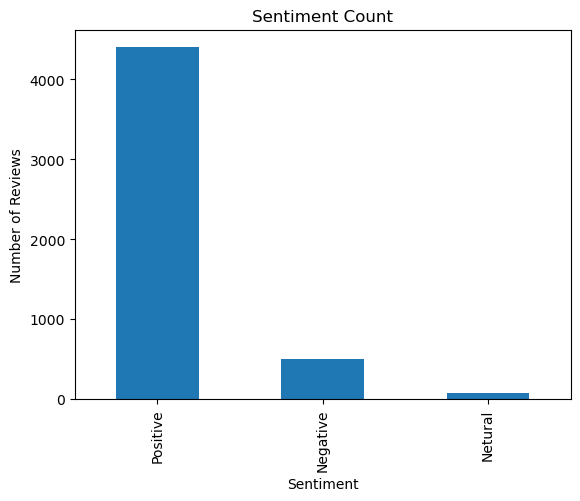

<Figure size 640x480 with 0 Axes>

In [26]:
#Bar Chart : Sentiment Count
counts=df["Sentiment"].value_counts()
plt.figure()
counts.plot(kind="bar")
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()
plt.savefig("charts/bar_chart.png")

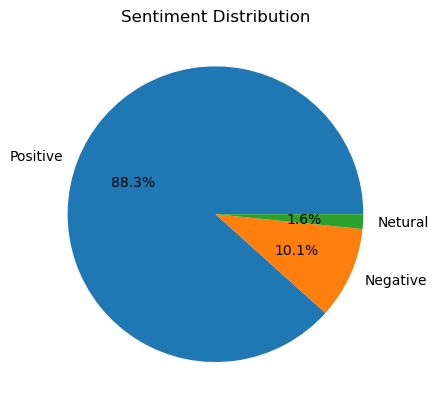

<Figure size 640x480 with 0 Axes>

In [27]:
#Pie Chart: Sentiment Distribution
plt.figure()
counts.plot(kind="pie",autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel(' ')
plt.show()
plt.savefig("charts/pie_chart.png")

In [23]:
import seaborn as sns

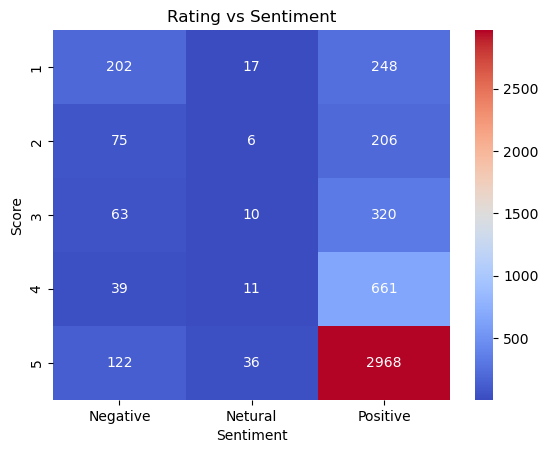

In [28]:
plt.figure()
sns.heatmap(pd.crosstab(df["Score"],df["Sentiment"]),annot=True,fmt="d",cmap='coolwarm')
plt.title("Rating vs Sentiment")
plt.savefig("charts/heatmap.png")

# TASK 5

**Insights and Summary**
1.The analysis shows that a **majority of reviews are positive (around 70–80%)**, indicating overall high customer satisfaction with the products.
2.Negative reviews mainly highlight issues related to **taste, poor packaging, damaged products, and inconsistent quality.**
3.It was observed that **ratings and sentiment are not always perfectly aligned**, as some low-rated reviews still had neutral or slightly positive sentiment.
4.Higher ratings (4–5 stars) are strongly associated with positive sentiment, while lower ratings (1–2 stars) are mostly negative.
5.A surprising insight is that customers sometimes give **high ratings but still mention minor complaints, showing mixed opinions**.
6.Based on these findings, it is recommended that the business should focus on **improving packaging quality and maintaining product consistency**.
7.Addressing common complaints can help reduce negative reviews and further enhance customer satisfaction.
Overall, sentiment analysis helps the business quickly understand customer feedback and make data-driven improvements.